In [236]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [238]:
df = yf.download('BTC-USD', period='max',interval='1m')
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Datetime,,,,,
2026-03-22 10:35:00+00:00,68702.000000,68702.000000,68702.000000,68702.000000,0
2026-03-22 10:36:00+00:00,68643.343750,68643.343750,68643.343750,68643.343750,0
2026-03-22 10:37:00+00:00,68664.617188,68664.617188,68664.617188,68664.617188,0
2026-03-22 10:38:00+00:00,68689.554688,68689.554688,68689.554688,68689.554688,0
2026-03-22 10:39:00+00:00,68682.578125,68682.578125,68682.578125,68682.578125,753664
...,...,...,...,...,...
2026-03-30 10:27:00+00:00,67391.453125,67391.453125,67391.453125,67391.453125,405504
2026-03-30 10:28:00+00:00,67377.710938,67377.710938,67377.710938,67377.710938,0


In [239]:
#multiindex
if isinstance(df.columns,pd.MultiIndex):
    df.columns=df.columns.map(lambda x:x[0])

In [240]:
df= df.reset_index()

In [241]:
# Prophet data Engineering
df = df.rename(columns={'Datetime':'ds','Close':'y'})

In [242]:
df = df.sort_values('ds')

In [243]:
df['ds'] = pd.to_datetime(df['ds']).dt.tz_localize(None)

In [244]:
df.head()

,ds,y,High,Low,Open,Volume
0,2026-03-22 10:35:00,68702.000000,68702.000000,68702.000000,68702.000000,0
1,2026-03-22 10:36:00,68643.343750,68643.343750,68643.343750,68643.343750,0
2,2026-03-22 10:37:00,68664.617188,68664.617188,68664.617188,68664.617188,0
3,2026-03-22 10:38:00,68689.554688,68689.554688,68689.554688,68689.554688,0
4,2026-03-22 10:39:00,68682.578125,68682.578125,68682.578125,68682.578125,753664


In [245]:
# Indicators
df['ema10'] = df.y.ewm(min_periods=10, span=10).mean()
df['ema12'] = df.y.ewm(min_periods=12, span=12).mean()
df['ema20'] = df.y.ewm(min_periods=20, span=20).mean()
df['ema26'] = df.y.ewm(min_periods=26, span=26).mean()
df['ema50'] = df.y.ewm(min_periods=50, span=50).mean()
df['ema200'] = df.y.ewm(min_periods=200, span=200).mean()
df['MACD'] = df['ema26'] - df['ema12']
df['MACD_signal']=df.MACD.ewm(min_periods=9, span=9).mean()

In [246]:
df=df.dropna()

In [247]:
train, test = df[:-60], df[-60:]

In [248]:
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

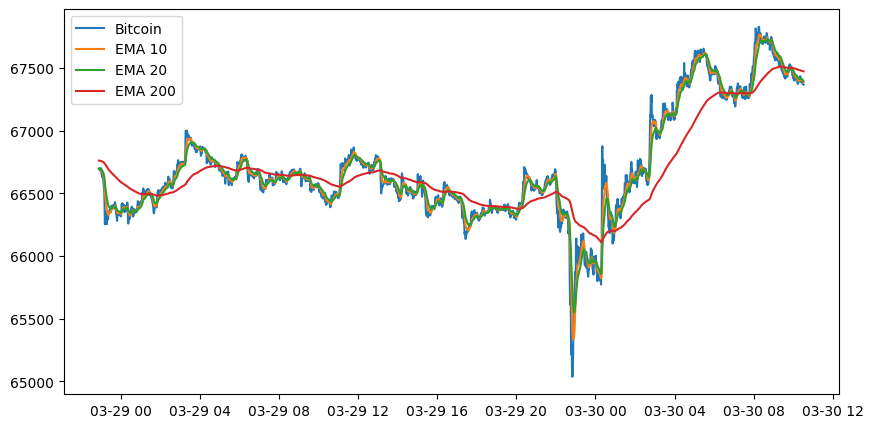

In [249]:
plt.figure(figsize=(10,5))
plt.plot(test['ds'], test['y'], label= 'Bitcoin')
plt.plot(test['ds'], test['ema10'], label= 'EMA 10')
plt.plot(test['ds'], test['ema20'], label= 'EMA 20')
plt.plot(test['ds'], test['ema200'], label= 'EMA 200')
plt.legend()
plt.show()

In [250]:
# Regressors
X=['ema10','ema20','ema12','ema26','ema50','ema200','MACD','MACD_signal']

In [251]:
# Prophet model
model=Prophet()
#model.add_seasonality(name='intraday', period=1, fourier_order=15)

In [252]:
# add regressors
for x in X:
    model.add_regressor(x, standardize='auto')

In [253]:
print(df['ds'].iloc[0])
print(df['ds'].dtype)

2026-03-22 14:06:00
datetime64[ns]


In [254]:
# fit model
model.fit(train)

11:40:49 - cmdstanpy - INFO - Chain [1] start processing
11:41:02 - cmdstanpy - INFO - Chain [1] done processing


In [255]:
#predict
predicted = model.predict(test)

In [256]:
# Compute accuracy metrics
rmse = np.sqrt(mean_squared_error(test['y'], predicted['yhat']))
mae = mean_absolute_error(test['y'], predicted['yhat'])
r2 = r2_score(test['y'], predicted['yhat'])
mape = mean_absolute_percentage_error(test['y'], predicted['yhat'])

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:4f}")

RMSE: 47.7227
MAE: 38.9635
R² Score: 0.9881
MAPE: 0.000585


In [229]:
test = test.copy()
test['naive'] = test['y'].shift(1)


rmse_naive = np.sqrt(mean_squared_error(test['y'][1:], test['naive'][1:]))
mae_naive = mean_absolute_error(test['y'][1:], test['naive'][1:])

print("Naive RMSE:", rmse_naive)
print("Naive MAE:", mae_naive)

Naive RMSE: 23.38077080690254
Naive MAE: 14.587453641780156


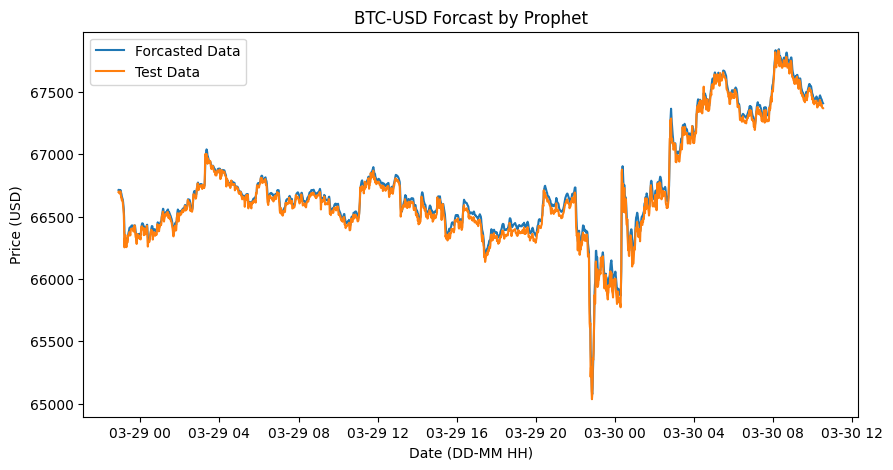

In [257]:
# Plot test data vs forecasted data
plt.figure(figsize=(10, 5))
plt.plot(test['ds'], predicted['yhat'], label='Forcasted Data')
plt.plot(test['ds'], test['y'], label='Test Data')
plt.title('BTC-USD Forcast by Prophet')
plt.xlabel('Date (DD-MM HH)')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [258]:
test.tail(1)

,ds,y,High,Low,Open,Volume,ema10,ema12,ema20,ema26,ema50,ema200,MACD,MACD_signal
10522,2026-03-30 10:31:00,67368.429688,67368.429688,67368.429688,67368.429688,0,67385.667533,67388.318349,67397.275857,67403.702423,67430.494516,67474.109362,15.384074,13.539734


In [259]:
# Create a DataFrame for the specific future date
future = pd.DataFrame({
    'ds': pd.to_datetime(['2026-03-30 10:31:01']),  
    'High': [df['High'].iloc[-1]], 
    'Low': [df['Low'].iloc[-1]],    
    'Open': [df['Open'].iloc[-1]],  
    'Volume': [df['Volume'].iloc[-1]],
    'ema10': [df['ema10'].iloc[-1]],
     'ema12': [df['ema12'].iloc[-1]],
     'ema20': [df['ema20'].iloc[-1]],
     'ema26': [df['ema26'].iloc[-1]],
    'ema50':[df['ema50'].iloc[-1]],
    'ema200':[df['ema200'].iloc[-1]],
    'MACD':[df['MACD'].iloc[-1]],
    'MACD_signal':[df['MACD_signal'].iloc[-1]]
    })

In [260]:
# Generate forecasts
forecast = model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,MACD,MACD_lower,MACD_upper,MACD_signal,...,ema50,ema50_lower,ema50_upper,extra_regressors_additive,extra_regressors_additive_lower,extra_regressors_additive_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2026-03-30 10:31:01,68957.491541,67365.164916,67450.843146,68957.491541,68957.491541,-285.71581,-285.71581,-285.71581,116.73043,...,-790.299496,-790.299496,-790.299496,-1547.487274,-1547.487274,-1547.487274,0.0,0.0,0.0,67407.315789


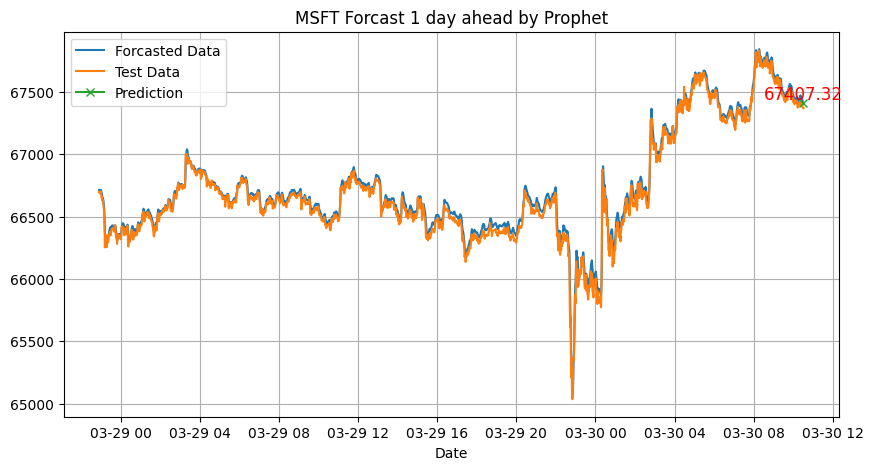

In [262]:
# Plot test data vs forecasted data
plt.figure(figsize=(10, 5))
plt.plot(test['ds'], predicted['yhat'], label='Forcasted Data')
plt.plot(test['ds'], test['y'], label='Test Data')
plt.plot(forecast['ds'], forecast['yhat'], label='Prediction', marker='x',)
#plt.axvline(pd.Timestamp('2026-03-04'), color='r', linestyle='--') 
for index, row in forecast.iterrows():
    plt.text(row['ds'], row['yhat'], f"{row['yhat']:.2f}", color='red', fontsize=12, ha='center', va='bottom')
plt.title('MSFT Forcast 1 day ahead by Prophet')
plt.xlabel('Date')
plt.grid()
plt.legend()
plt.show()

### Cross-Validation

In [231]:
from prophet.diagnostics import cross_validation

df_cv = cross_validation(
    model,
    initial='3 days',     # training window
    period='6 hours',      # spacing between cutoffs
    horizon='6 hours'      # forecast horizon
)

  0%|          | 0/13 [00:00<?, ?it/s]

15:27:03 - cmdstanpy - INFO - Chain [1] start processing
15:27:11 - cmdstanpy - INFO - Chain [1] done processing
15:27:12 - cmdstanpy - INFO - Chain [1] start processing
15:27:18 - cmdstanpy - INFO - Chain [1] done processing
15:27:19 - cmdstanpy - INFO - Chain [1] start processing
15:27:26 - cmdstanpy - INFO - Chain [1] done processing
15:27:27 - cmdstanpy - INFO - Chain [1] start processing
15:27:39 - cmdstanpy - INFO - Chain [1] done processing
15:27:40 - cmdstanpy - INFO - Chain [1] start processing
15:27:52 - cmdstanpy - INFO - Chain [1] done processing
15:27:53 - cmdstanpy - INFO - Chain [1] start processing
15:28:05 - cmdstanpy - INFO - Chain [1] done processing
15:28:06 - cmdstanpy - INFO - Chain [1] start processing
15:28:18 - cmdstanpy - INFO - Chain [1] done processing
15:28:19 - cmdstanpy - INFO - Chain [1] start processing
15:28:30 - cmdstanpy - INFO - Chain [1] done processing
15:28:31 - cmdstanpy - INFO - Chain [1] start processing
15:28:38 - cmdstanpy - INFO - Chain [1]

In [232]:
from prophet.diagnostics import performance_metrics

df_perf = performance_metrics(df_cv)
print(df_perf.head())

          horizon          mse       rmse        mae      mape     mdape  \
0 0 days 00:37:00  1213.828737  34.840045  24.563849  0.000355  0.000256   
1 0 days 00:38:00  1203.544330  34.692136  24.605176  0.000355  0.000256   
2 0 days 00:39:00  1198.601860  34.620830  24.581740  0.000355  0.000257   
3 0 days 00:40:00  1156.794082  34.011676  24.046360  0.000347  0.000246   
4 0 days 00:41:00  1136.855017  33.717281  23.886246  0.000345  0.000246   

      smape  coverage  
0  0.000355  0.851663  
1  0.000355  0.853685  
2  0.000355  0.853685  
3  0.000347  0.858167  
4  0.000345  0.861754  


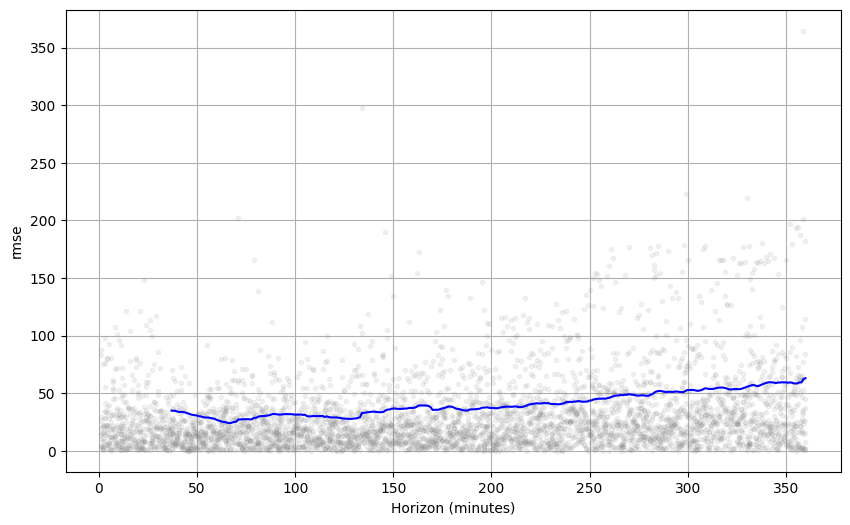

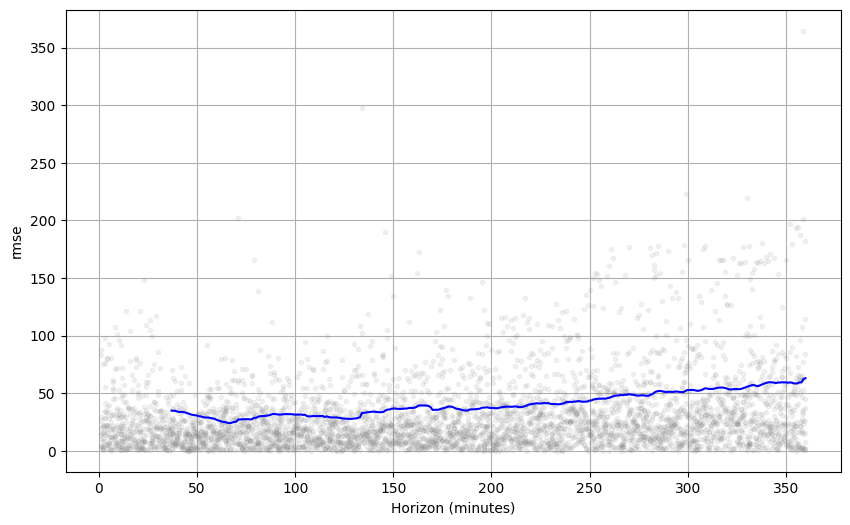

In [237]:
from prophet.plot import plot_cross_validation_metric

plot_cross_validation_metric(df_cv, metric='rmse')